# QKD-Backed Pairwise-Masked Federated Learning for Channel Estimation

**Scope.** This notebook implements a **protocol-level BB84-style QKD abstraction** to provide shared random keys that drive **pairwise additive masking** (Bonawitz-style) for secure aggregation in federated learning, applied to a channel-estimation task. We explicitly operate at the **protocol level**; detailed **physical-layer / MDI-QKD modeling is out of scope**.

In [1]:
# SECTION 1 — Imports, Device, Global Config

import os
import math
import time
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import pandas as pd
import scipy.io
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

# Device selection (prefer MPS on Apple Silicon, then CUDA, then CPU)
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

# Global FL / QKD / experiment knobs
NUM_CLIENTS   = 3          # Number of federated clients
NUM_ROUNDS    = 20          # FL rounds per experiment
LOCAL_EPOCHS  = 30          # Local epochs per client per round
BATCH_SIZE    = 16         # Training batch size
LEARNING_RATE = 5e-4       # Client optimizer LR

KEY_BIT_LENGTH = 2000      # QKD raw key length per round
QBER_THRESHOLD = 0.08      # Abort if estimated QBER >= threshold
MASK_SCALE     = 1e-3      # Scale for additive pairwise masks

MAX_SAMPLES   = 1000       # Cap on dataset size for runtime
SEEDS         = [0]        # Can sweep later if desired
FORCE_RECOMPUTE = False    # Re-run experiments even if cached

# Results directory and run ID (all outputs under ChannelEstimation/)
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
RESULTS_DIR = os.path.join("ChannelEstimation", RUN_ID)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, "pub"), exist_ok=True)

print(f"RUN_ID     = {RUN_ID}")
print(f"RESULTS_DIR= {RESULTS_DIR}")

Using device: mps
RUN_ID     = 20260427_092752
RESULTS_DIR= ChannelEstimation/20260427_092752


## TVT Revision: Utilities, Scalability, Overhead, Classical-SA Baseline

**What was changed (TVT revision):**
- Added scalability experiments with K ∈ {3, 10, 20} clients
- Added communication + compute overhead analysis per round (bytes, masking time, keygen time)
- Added **Classical-SA** baseline: same pairwise additive masking, but keys derived via deterministic PRG (simulated ECDH) instead of QKD
- Three modes: **Plain FL** (no masking) | **Classical-SA** (pairwise masking + classical keys) | **QKD-SA** (pairwise masking + QKD-derived keys)
- Results saved to `./outputs/channel_estimation/`

In [2]:
# Utilities: device, seeding, timing, byte counting (TVT)

import hashlib
import pickle
from contextlib import contextmanager

def get_device():
    """Prefer MPS (Apple Silicon), then CUDA, then CPU."""
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

def set_global_seed(seed):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

@contextmanager
def Timer():
    """Context manager for wall-clock measurements."""
    t0 = time.perf_counter()
    yield lambda: time.perf_counter() - t0

def model_size_bytes(model_or_state_dict):
    """Exact byte size of all tensors (numel * element_size)."""
    sd = model_or_state_dict if isinstance(model_or_state_dict, dict) else model_or_state_dict.state_dict()
    return sum(v.numel() * v.element_size() for v in sd.values())

def serialize_size_bytes(obj):
    """Optional: pickle size for sanity checks."""
    return len(pickle.dumps(obj))

def ensure_output_dirs(task="channel_estimation"):
    base = os.path.join("outputs", task)
    os.makedirs(base, exist_ok=True)
    os.makedirs(os.path.join(base, "figures"), exist_ok=True)
    return base

def save_figure(fig, name, task="channel_estimation"):
    base = ensure_output_dirs(task)
    path = os.path.join(base, "figures", name)
    fig.savefig(path, bbox_inches="tight", dpi=150)
    plt.close(fig)

In [3]:
# Client partitioning for K in {3, 10, 20} (TVT)

def partition_dataset_indices(N, K, labels=None, non_iid=True, alpha=0.5, seed=42):
    """
    Partition N indices into K client shards.
    - non_iid=False: equal random splits
    - non_iid=True: Dirichlet over proxy; for channel est use mean |Y|; for radar use class distribution
    """
    set_global_seed(seed)
    indices = np.arange(N)
    if not non_iid:
        np.random.shuffle(indices)
        shards = np.array_split(indices, min(K, N))
        return [s for s in shards if len(s) > 0]
    # Proxy for partitioning (continuous labels -> bucket by magnitude)
    if labels is not None and labels.size > 0:
        flat = labels.reshape(N, -1)
        proxy = np.mean(np.abs(flat), axis=1)
    else:
        proxy = np.random.rand(N)
    # Bucket into K quantile groups, then shuffle within for slight randomness
    sorted_idx = np.argsort(proxy)
    shards = np.array_split(sorted_idx, K)
    return [s for s in shards if len(s) > 0]

In [4]:
# Classical-SA key derivation + TVT masking (STEP 3)

def derive_pairwise_key_classical(i, j, round_id, base_seed, bit_length):
    """Symmetric: k_ij == k_ji. Simulated ECDH/PRG with format: base_seed|round_id|min|max."""
    lo, hi = min(i, j), max(i, j)
    seed_str = f"{base_seed}|{round_id}|{lo}|{hi}"
    h = hashlib.sha256(seed_str.encode()).digest()
    bits = []
    idx = 0
    while len(bits) < bit_length:
        h = hashlib.sha256(seed_str.encode() + idx.to_bytes(4, 'big')).digest()
        for b in h:
            for k in range(8):
                if len(bits) < bit_length:
                    bits.append((b >> (7 - k)) & 1)
        idx += 1
    return bits[:bit_length]


def derive_pairwise_key_qkd(round_key_bits, i, j, bit_length):
    """Expand round QKD key into pairwise key for (i,j). Symmetric: k_ij == k_ji."""
    lo, hi = min(i, j), max(i, j)
    # Convert round key bits to bytes for hashing
    kb = bytearray()
    for idx in range(0, len(round_key_bits), 8):
        byte_val = 0
        for jj in range(8):
            if idx + jj < len(round_key_bits):
                byte_val = (byte_val << 1) | round_key_bits[idx + jj]
        kb.append(byte_val)
    seed_str = f"{lo}|{hi}"
    h = hashlib.sha256(bytes(kb) + seed_str.encode()).digest()
    bits = []
    idx = 0
    while len(bits) < bit_length:
        h = hashlib.sha256(bytes(kb) + seed_str.encode() + idx.to_bytes(4, 'big')).digest()
        for b in h:
            for k in range(8):
                if len(bits) < bit_length:
                    bits.append((b >> (7 - k)) & 1)
        idx += 1
    return bits[:bit_length]


def apply_pairwise_masks_tvt(local_state_dict, client_id, round_id, num_clients, base_seed, bit_length, dev,
                             key_source="classical", round_key_bits=None):
    """Apply pairwise masks. key_source: 'classical' | 'qkd'.
    For 'qkd', round_key_bits must be provided (from BB84 per round)."""
    def get_bits(j):
        if key_source == "classical":
            return derive_pairwise_key_classical(client_id, j, round_id, base_seed, bit_length)
        if key_source == "qkd":
            assert round_key_bits is not None, "QKD mode requires round_key_bits"
            return derive_pairwise_key_qkd(round_key_bits, client_id, j, bit_length)
        raise ValueError(f"key_source must be 'classical' or 'qkd', got {key_source}")

    masked = {}
    for n, p in local_state_dict.items():
        masked_p = p.detach().clone().float().to(dev)
        for j in range(num_clients):
            if j == client_id:
                continue
            bits = get_bits(j)
            m = mask_from_bits(bits, p.shape, scale=MASK_SCALE, dev=dev)
            masked_p = masked_p + m if client_id < j else masked_p - m
        masked[n] = masked_p.detach().cpu()

    assert len(masked) == len(local_state_dict), "Pairwise masking did not cover all parameters"
    return masked

Loaded channel-estimation MAT file.
  trainData shape : (480, 612, 14, 1)
  trainLabels shape: (480, 612, 14, 1)
  valData shape   : (32, 612, 14, 1)
  valLabels shape : (32, 612, 14, 1)

[Data sanity checks]
Train X min/max: -13.832 / 10.009
Train Y min/max: -2.788 / 3.068
Number of clients: 3
  Client 0: 160 samples
  Client 1: 160 samples
  Client 2: 160 samples


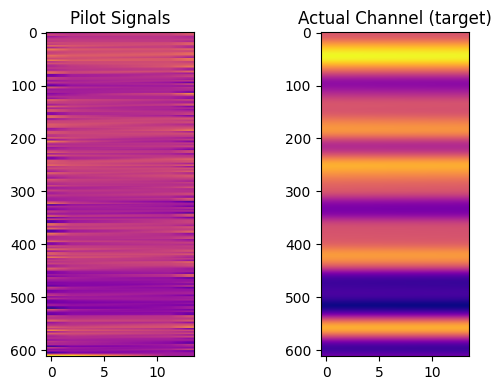

In [5]:
# SECTION 2 — Channel Estimation Dataset Loader

"""This section adapts the channel-estimation data pipeline from
`Channel_Estimation_Book_Chapter_2.ipynb` into a lightweight PyTorch
Dataset / DataLoader interface suitable for FL experiments.

Primary path:
- Expect a local `data.mat` file with keys: trainData, trainLabels, valData, valLabels
  shaped (H, W, C, N) as in the original notebook; we transpose to (N, H, W, C).

Fallback path:
- If `data.mat` is missing, synthesize a small Rayleigh-fading style dataset
  with pilot matrices X and complex channel responses H (magnitude only).
"""

DATA_MAT_PATH = "data.mat"  # expected to live in current working directory


def _load_mat_or_none(path: str):
    if not os.path.exists(path):
        return None
    try:
        data = scipy.io.loadmat(path)
        return data
    except Exception as e:
        print(f"Failed to load {path} ({e}); using synthetic fallback.")
        return None


def _prepare_from_mat(max_samples: int):
    data = _load_mat_or_none(DATA_MAT_PATH)
    if data is None:
        return None

    # Original shapes: (H, W, C, N). We bring N to front.
    def _tx(arr):
        return arr.transpose((3, 0, 1, 2))

    trainData  = _tx(data["trainData"])
    trainLabels = _tx(data["trainLabels"])
    valData    = _tx(data["valData"])
    valLabels  = _tx(data["valLabels"])

    # Optionally subsample to keep runtime reasonable
    def _subsample(x, y, k):
        n = min(k, x.shape[0])
        return x[:n], y[:n]

    trainData, trainLabels = _subsample(trainData, trainLabels, max_samples)
    valData,   valLabels   = _subsample(valData,   valLabels,   max_samples // 2)

    print("Loaded channel-estimation MAT file.")
    print(f"  trainData shape : {trainData.shape}")
    print(f"  trainLabels shape: {trainLabels.shape}")
    print(f"  valData shape   : {valData.shape}")
    print(f"  valLabels shape : {valLabels.shape}")

    return trainData, trainLabels, valData, valLabels



class ChannelEstimationDataset(Dataset):
    def __init__(self, X: np.ndarray, Y: np.ndarray):
        """X, Y are numpy arrays of shape (N, H, W, 1)."""
        assert X.shape == Y.shape, f"X {X.shape} != Y {Y.shape}"
        self.X = torch.from_numpy(X).float()  # (N, H, W, 1)
        self.Y = torch.from_numpy(Y).float()  # (N, H, W, 1)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]  # (H, W, 1)
        y = self.Y[idx]
        # Convert to NCHW for PyTorch conv2d: (C, H, W)
        x = x.permute(2, 0, 1)  # 1 x H x W
        y = y.permute(2, 0, 1)  # 1 x H x W
        return x, y


# Materialize dataset
mat_result = _prepare_from_mat(MAX_SAMPLES)

if mat_result is None:
    raise FileNotFoundError(
        "data.mat was not found. Stop here. "
        "Do not use synthetic fallback for paper results."
    )

trainData, trainLabels, valData, valLabels = mat_result

# Train/val split is already present if using MAT; if synthetic, we created both.

# Sanity prints / data quality checks
print("\n[Data sanity checks]")
print(f"Train X min/max: {trainData.min():.3f} / {trainData.max():.3f}")
print(f"Train Y min/max: {trainLabels.min():.3f} / {trainLabels.max():.3f}")

train_dataset = ChannelEstimationDataset(trainData, trainLabels)
val_dataset   = ChannelEstimationDataset(valData,   valLabels)

# Partition training data into NUM_CLIENTS shards (contiguous for simplicity)
indices = np.arange(len(train_dataset))
np.random.shuffle(indices)
shards = np.array_split(indices, NUM_CLIENTS)

client_loaders = []
for cid, shard_idx in enumerate(shards):
    subset_X = trainData[shard_idx]
    subset_Y = trainLabels[shard_idx]
    ds = ChannelEstimationDataset(subset_X, subset_Y)
    dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True)
    client_loaders.append(dl)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of clients: {NUM_CLIENTS}")
for cid, shard_idx in enumerate(shards):
    print(f"  Client {cid}: {len(shard_idx)} samples")

# Qualitative example: show one pilot vs actual channel snapshot
example_idx = 0
ex_x = trainData[example_idx:example_idx+1, :, :, 0]  # (1, H, W)
ex_y = trainLabels[example_idx:example_idx+1, :, :, 0]

fig, ax = plt.subplots(1, 2, figsize=(6, 4))
im0 = ax[0].imshow(ex_x[0], aspect=0.05, cmap='plasma')
ax[0].set_title('Pilot Signals')
im1 = ax[1].imshow(ex_y[0], aspect=0.05, cmap='plasma')
ax[1].set_title('Actual Channel (target)')
plt.tight_layout()
plt.show()

In [6]:
# SECTION 3 — Channel Estimation Model and Training/Eval Helpers

"""We reuse the small CNN architecture from the channel-estimation
notebook, adapted to PyTorch:

- Conv2d(1 -> 48, kernel 9x9, padding='same', activation=selu)
- Conv2d(48 -> 16, kernel 5x5, padding='same', activation=softplus)
- Conv2d(16 -> 1, kernel 5x5, padding='same', activation=selu)

The model maps pilot spectrograms (1 x 612 x 14) to channel magnitude
(1 x 612 x 14). We use MSE as the main loss, and report MSE + NMSE.
"""


class ChannelEstimationCNN(nn.Module):
    def __init__(self, mult_factor: float = 1.0):
        super().__init__()
        c1 = int(48 * mult_factor)
        c2 = int(16 * mult_factor)
        self.net = nn.Sequential(
            nn.Conv2d(1,  c1, kernel_size=(9, 9), padding=4),  # 9x9 same padding
            nn.SELU(inplace=True),
            nn.Conv2d(c1, c2, kernel_size=(5, 5), padding=2),
            nn.Softplus(),
            nn.Conv2d(c2, 1,  kernel_size=(5, 5), padding=2),
            # nn.SELU(inplace=True),
            nn.Softplus(),
        )

    def forward(self, x):
        return self.net(x)


def nmse_metric(y_hat: torch.Tensor, y_true: torch.Tensor) -> float:
    """Compute NMSE = E[||y_hat - y||^2] / E[||y||^2] over a batch."""
    num = torch.sum((y_hat - y_true) ** 2).item()
    den = torch.sum((y_true) ** 2).item() + 1e-12
    return num / den


def train_client(model: nn.Module,
                 loader: DataLoader,
                 epochs: int = LOCAL_EPOCHS,
                 lr: float = LEARNING_RATE) -> dict:
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.MSELoss()
    for _ in range(epochs):
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            opt.zero_grad()
            y_hat = model(x)
            loss = crit(y_hat, y)
            loss.backward()
            opt.step()
    # Return a *CPU* state_dict for later masking / aggregation
    return {k: v.detach().cpu() for k, v in model.state_dict().items()}


def evaluate(model: nn.Module, loader: DataLoader) -> dict:
    model.eval()
    mse_sum, nmse_sum, n_batches = 0.0, 0.0, 0
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            y_hat = model(x)
            mse = nn.functional.mse_loss(y_hat, y, reduction='mean').item()
            nmse = nmse_metric(y_hat, y)
            mse_sum  += mse
            nmse_sum += nmse
            n_batches += 1
    if n_batches == 0:
        return {"mse": float('nan'), "nmse": float('nan')}
    return {
        "mse":  mse_sum / n_batches,
        "nmse": nmse_sum / n_batches,
    }


# Quick smoke test on a tiny batch to ensure shapes are consistent
_test_model = ChannelEstimationCNN().to(device)
_test_batch = next(iter(val_loader))[0].to(device)
with torch.no_grad():
    _out = _test_model(_test_batch)
print(f"Model smoke test: in={_test_batch.shape}, out={_out.shape}")

Model smoke test: in=torch.Size([16, 1, 612, 14]), out=torch.Size([16, 1, 612, 14])


In [7]:
# SECTION 4 — BB84-Style QKD Abstraction + Pairwise Masking

"""This section reuses the protocol-level BB84 abstraction and pairwise
masking utilities from the radar QKD+FL notebook, keeping the
interfaces and logging semantics consistent.

Key functions:
- generate_bb84_abstraction_key(bit_length, seed, pa_ratio, eve_present, channel_noise)
    -> (alice_key, bob_key, sifted_len, final_len, qber)
- derive_pairwise_key(i, j, round_id, base_seed, bit_length)
- mask_from_bits(bits, shape, scale, dev)
- apply_pairwise_masks(local_state_dict, client_id, round_id, num_clients, base_seed, bit_length, dev)

We also provide helpers for reconstruction error and leakage proxies.
"""

import hashlib
import random

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error


def _privacy_amplify(sifted_key, final_len):
    sifted_len = len(sifted_key)
    sifted_bytes = bytearray()
    for i in range(0, sifted_len, 8):
        byte_val = 0
        for j in range(8):
            if i + j < sifted_len:
                byte_val = (byte_val << 1) | sifted_key[i + j]
        sifted_bytes.append(byte_val)
    sifted_bytes = bytes(sifted_bytes)
    final_key, idx = [], 0
    while len(final_key) < final_len:
        h = hashlib.sha256(sifted_bytes + idx.to_bytes(4, 'big')).digest()
        for b in h:
            for j in range(8):
                if len(final_key) < final_len:
                    final_key.append((b >> (7 - j)) & 1)
        idx += 1
    return final_key


def generate_bb84_abstraction_key(bit_length,
                                  seed=None,
                                  pa_ratio=0.8,
                                  eve_present=False,
                                  channel_noise=0.0,
                                  silent=True):
    """Protocol-level BB84 abstraction.

    Returns (alice_key, bob_key, sifted_len, final_len, qber).
    - eve_present: if True, model an intercept-resend Eve that raises QBER.
    - channel_noise: depolarizing noise strength (when simulating via Qiskit).
    """
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    alice_bits  = [random.randint(0, 1) for _ in range(bit_length)]
    alice_bases = [random.randint(0, 1) for _ in range(bit_length)]
    bob_bases   = [random.randint(0, 1) for _ in range(bit_length)]
    eve_bases   = [random.randint(0, 1) for _ in range(bit_length)] if eve_present else None

    if eve_present:
        bob_bits = []
        for i in range(bit_length):
            eve_bit = alice_bits[i] if alice_bases[i] == eve_bases[i] else random.randint(0, 1)
            bob_bit = eve_bit if bob_bases[i] == eve_bases[i] else random.randint(0, 1)
            if channel_noise > 0 and random.random() < channel_noise:
                bob_bit = 1 - bob_bit
            bob_bits.append(bob_bit)
        sifted_idx = [i for i in range(bit_length) if alice_bases[i] == bob_bases[i]]
        alice_s = [alice_bits[i] for i in sifted_idx]
        bob_s   = [bob_bits[i]   for i in sifted_idx]
        sifted_len = len(alice_s)
        qber = sum(a != b for a, b in zip(alice_s, bob_s)) / sifted_len if sifted_len else 0.0
        final_len = max(256, int(sifted_len * pa_ratio))
        return _privacy_amplify(alice_s, final_len), _privacy_amplify(bob_s, final_len), sifted_len, final_len, qber

    # Qiskit BB84 quantum simulation (no Eve, optional depolarizing noise)
    if channel_noise > 0:
        nm = NoiseModel()
        nm.add_all_qubit_quantum_error(depolarizing_error(channel_noise, 1), ['x', 'h'])
        sim = AerSimulator(noise_model=nm)
    else:
        sim = AerSimulator()

    bob_bits = []
    for i in range(bit_length):
        qc = QuantumCircuit(1, 1)
        if alice_bits[i]:
            qc.x(0)
        if alice_bases[i]:
            qc.h(0)
        if bob_bases[i]:
            qc.h(0)
        qc.measure(0, 0)
        out = list(sim.run(qc, shots=1).result().get_counts().keys())[0]
        bob_bits.append(int(out))

    sifted_idx = [i for i in range(bit_length) if alice_bases[i] == bob_bases[i]]
    sifted_key = [bob_bits[i] for i in sifted_idx]
    alice_s    = [alice_bits[i] for i in sifted_idx]
    sifted_len = len(sifted_key)
    qber = sum(a != b for a, b in zip(alice_s, sifted_key)) / sifted_len if sifted_len else 0.0
    final_len = max(256, int(sifted_len * pa_ratio))
    key_bits = _privacy_amplify(sifted_key, final_len)
    return key_bits, key_bits, sifted_len, final_len, qber


# --- Pairwise Masking (Bonawitz-style) ---


def derive_pairwise_key(i, j, round_id, base_seed, bit_length):
    """Symmetric: k_ij == k_ji. Deterministic per (i,j,round)."""
    lo, hi = min(i, j), max(i, j)
    seed_str = f"{lo}|{hi}|{round_id}|{base_seed}"
    h = hashlib.sha256(seed_str.encode()).digest()
    bits = []
    idx = 0
    while len(bits) < bit_length:
        h = hashlib.sha256(seed_str.encode() + idx.to_bytes(4, 'big')).digest()
        for b in h:
            for k in range(8):
                if len(bits) < bit_length:
                    bits.append((b >> (7 - k)) & 1)
        idx += 1
    return bits[:bit_length]


def mask_from_bits(bits, shape, scale=MASK_SCALE, dev=None):
    """Deterministic mask from bits: +/- scale per element. Returns tensor on dev if given."""
    flat = int(np.prod(shape))
    m = np.array([scale if bits[i % len(bits)] else -scale for i in range(flat)], dtype=np.float32).reshape(shape)
    t = torch.from_numpy(m)
    return t.to(dev) if dev is not None else t


def apply_pairwise_masks_old(local_state_dict, client_id, round_id, num_clients, base_seed, bit_length, dev):
    """Apply pairwise additive masks. Returns masked state_dict on CPU."""
    masked = {}
    for n, p in local_state_dict.items():
        masked_p = p.detach().clone().float().to(dev)
        for j in range(num_clients):
            if j == client_id:
                continue
            bits = derive_pairwise_key(client_id, j, round_id, base_seed, bit_length)
            m = mask_from_bits(bits, p.shape, scale=MASK_SCALE, dev=dev)
            masked_p = masked_p + m if client_id < j else masked_p - m
        masked[n] = masked_p.detach().cpu()

    assert len(masked) == len(local_state_dict), "Pairwise masking did not cover all parameters"
    return masked

def apply_pairwise_masks(local_state_dict,
                         client_id,
                         round_id,
                         num_clients,
                         base_seed,
                         bit_length,
                         dev,
                         use_qkd_key=False,
                         round_key_bits=None):
    """
    Apply pairwise additive masks.

    Modes:
    - use_qkd_key=False  -> classical deterministic pairwise keys from base_seed
    - use_qkd_key=True   -> pairwise keys derived from round_key_bits (QKD round seed)

    Returns masked state_dict on CPU.
    """
    masked = {}

    for n, p in local_state_dict.items():
        masked_p = p.detach().clone().float().to(dev)

        for j in range(num_clients):
            if j == client_id:
                continue

            if use_qkd_key:
                if round_key_bits is None:
                    raise ValueError("QKD masking requires round_key_bits")
                bits = derive_pairwise_key_qkd(round_key_bits, client_id, j, bit_length)
            else:
                bits = derive_pairwise_key(client_id, j, round_id, base_seed, bit_length)

            m = mask_from_bits(bits, p.shape, scale=MASK_SCALE, dev=dev)
            masked_p = masked_p + m if client_id < j else masked_p - m

        masked[n] = masked_p.detach().cpu()

    assert len(masked) == len(local_state_dict), "Pairwise masking did not cover all parameters"
    return masked


def average_state_dicts(lst, dev):
    return {n: torch.stack([s[n].float().to(dev) for s in lst]).mean(0) for n in lst[0].keys()}


# Leakage proxies and reconstruction correctness helpers

def _flatten_sd(sd: dict) -> np.ndarray:
    return np.concatenate([v.float().cpu().numpy().flatten() for v in sd.values()]).astype(np.float32)


def compute_leakage_proxies(true_delta_sd: dict, masked_delta_sd: dict) -> dict:
    """Cosine similarity, Pearson correlation, norm ratio, sign agreement.

    Intended to quantify information leaked by masked deltas relative
    to true deltas from an attacker perspective.
    """
    a = _flatten_sd(true_delta_sd)
    b = _flatten_sd(masked_delta_sd)
    a_norm = np.linalg.norm(a)
    b_norm = np.linalg.norm(b)
    if a_norm < 1e-12:
        return {"cosine": 0.0, "pearson": 0.0, "norm_ratio": 0.0, "sign_agreement": 0.5}
    cos = np.dot(a, b) / (a_norm * b_norm) if b_norm > 1e-12 else 0.0
    pearson = np.corrcoef(a, b)[0, 1] if len(a) > 1 and np.std(a) > 1e-12 and np.std(b) > 1e-12 else 0.0
    if np.isnan(pearson):
        pearson = 0.0
    norm_ratio = b_norm / a_norm if a_norm > 1e-12 else 0.0
    sign_agree = np.mean(np.sign(a) == np.sign(b)) if len(a) > 0 else 0.5
    return {
        "cosine": float(cos),
        "pearson": float(pearson),
        "norm_ratio": float(norm_ratio),
        "sign_agreement": float(sign_agree),
    }


# Sanity check: pairwise cancellation on synthetic tensors

def _sanity_check_pairwise():
    n_clients, round_id, base_seed = 3, 0, 123
    dev = device
    keys = ["a", "b"]
    shapes = [(10, 10), (5, 5)]
    plain = [{k: torch.randn(shapes[i], device=dev) for i, k in enumerate(keys)} for _ in range(n_clients)]
    masked = [apply_pairwise_masks(plain[c], c, round_id, n_clients, base_seed, 100, dev) for c in range(n_clients)]
    avg_plain = {k: torch.stack([p[k].float().to(dev) for p in plain]).mean(0) for k in keys}
    avg_masked = {k: torch.stack([m[k].float().to(dev) for m in masked]).mean(0) for k in keys}
    err = sum((avg_plain[k] - avg_masked[k]).norm().item() for k in keys)
    print(f"Pairwise cancellation error (should be ~0): {err:.2e}")
    assert err < 1e-4, "Pairwise masks did not cancel!"
    print("Pairwise cancellation: PASS")


_sanity_check_pairwise()

Pairwise cancellation error (should be ~0): 4.72e-07
Pairwise cancellation: PASS


In [8]:
# SECTION 5 — Federated Training Loop (run_experiment)

"""Federated training loop mirroring the radar notebook semantics.

run_experiment(n_rounds, n_clients, use_qkd, eve_every_round,
               channel_noise, client_data, val_loader)

Returns a dict with:
- round_nmse: list of NMSE per round
- round_mse : list of MSE per round
- leakage_cosine, leakage_pearson: per-round leakage proxies
- qber_history: per-round QBER
- key_lengths : per-round final key lengths
- round_status: list of 'SECURE' / 'ABORTED' / 'RECOVERED'
- round_metrics: list of dicts (one per round) with utility + security fields
"""


def run_experiment(n_rounds=NUM_ROUNDS,
                   n_clients=NUM_CLIENTS,
                   key_bits=KEY_BIT_LENGTH,
                   use_qkd=True,
                   eve_every_round=False,
                   channel_noise=0.0,
                   client_data=None,
                   val_loader=None):
    import time

    global_model = ChannelEstimationCNN().to(device)
    total_params = sum(p.numel() for p in global_model.parameters())

    round_nmse, round_mse = [], []
    qber_hist, key_lens = [], []
    status_log, round_metrics = [], []
    leakage_cos, leakage_pearson = [], []

    had_abort = False
    base_seed = 123  # shared per run for deterministic pairwise keys

    for r in tqdm(range(n_rounds), desc="Round", leave=False):
        t0 = time.perf_counter()

        eve_on = eve_every_round
        # --- QKD phase ---
        alice_key, bob_key, sifted, final_len, qber = generate_bb84_abstraction_key(
            bit_length=key_bits,
            seed=r * 42 + base_seed,
            eve_present=eve_on,
            channel_noise=channel_noise,
            silent=True,
        )
        qber_hist.append(qber)
        key_lens.append(final_len)

        if use_qkd and qber >= QBER_THRESHOLD:
            # Abort this round; keep global model frozen, log metrics
            status_log.append("ABORTED")
            had_abort = True
            metrics = evaluate(global_model, val_loader)
            round_nmse.append(metrics["nmse"])
            round_mse.append(metrics["mse"])
            leakage_cos.append(np.nan)
            leakage_pearson.append(np.nan)
            t1 = time.perf_counter()
            round_metrics.append({
                "round": r,
                "nmse": metrics["nmse"],
                "mse": metrics["mse"],
                "qber": qber,
                "status": "ABORTED",
                "bytes": 0,
                "round_time": t1 - t0,
                "recon_err": np.nan,
            })
            continue

        status = "RECOVERED" if had_abort else "SECURE"
        status_log.append(status)

        # --- Local training + (optionally) masking ---
        global_sd = {k: v.cpu().clone() for k, v in global_model.state_dict().items()}
        client_states = []
        plain_states = []
        bytes_sent = 0

        for c in tqdm(range(n_clients), desc="Clients", leave=False):
            cm = ChannelEstimationCNN().to(device)
            cm.load_state_dict(global_model.state_dict())
            local_sd_cpu = train_client(cm, client_data[c], epochs=LOCAL_EPOCHS)
            plain_states.append(local_sd_cpu)

            if use_qkd:
                # IMPORTANT: in QKD mode, derive pairwise masks from the BB84 round key,
                # not from the classical base_seed.
                masked = apply_pairwise_masks(
                    local_sd_cpu,
                    client_id=c,
                    round_id=r,
                    num_clients=n_clients,
                    base_seed=base_seed,
                    bit_length=key_bits,
                    dev=device,
                    use_qkd_key=True,
                    round_key_bits=alice_key
                )
                client_states.append(masked)
                bytes_sent += sum(p.numel() * 4 for p in masked.values())  # float32
            else:
                client_states.append(local_sd_cpu)
                bytes_sent += sum(p.numel() * 4 for p in local_sd_cpu.values())

        assert len(client_states) == n_clients, f"client_states={len(client_states)} != n_clients={n_clients}"

        # --- Aggregation and reconstruction correctness ---
        avg = average_state_dicts(client_states, device)
        recon_err = np.nan
        if use_qkd and plain_states:
            avg_plain = average_state_dicts(plain_states, device)
            recon_err = sum((avg_plain[k].float() - avg[k].float()).norm().item() for k in avg)

        global_model.load_state_dict(avg)
        metrics = evaluate(global_model, val_loader)
        t1 = time.perf_counter()

        # --- Leakage proxies for victim client (client 0) ---
        leakage_cos_r, leakage_pearson_r = np.nan, np.nan
        if use_qkd and plain_states:
            local_0_plain = plain_states[0]
            true_delta = {k: local_0_plain[k].float() - global_sd[k].float() for k in global_sd}
            masked_delta = {k: client_states[0][k].float() - global_sd[k].float() for k in global_sd}
            lp = compute_leakage_proxies(true_delta, masked_delta)
            leakage_cos_r, leakage_pearson_r = lp["cosine"], lp["pearson"]

        leakage_cos.append(leakage_cos_r)
        leakage_pearson.append(leakage_pearson_r)

        round_nmse.append(metrics["nmse"])
        round_mse.append(metrics["mse"])

        round_metrics.append({
            "round": r,
            "nmse": metrics["nmse"],
            "mse": metrics["mse"],
            "qber": qber,
            "status": status,
            "bytes": bytes_sent,
            "round_time": t1 - t0,
            "leakage_cosine": leakage_cos_r,
            "leakage_pearson": leakage_pearson_r,
            "recon_err": recon_err,
        })
        print(f"Round {r:02d}: {status} | NMSE={metrics['nmse']:.4e} | QBER={qber:.4f}")

    return {
        "round_nmse": round_nmse,
        "round_mse": round_mse,
        "leakage_cosine": leakage_cos,
        "leakage_pearson": leakage_pearson,
        "qber_history": qber_hist,
        "key_lengths": key_lens,
        "round_status": status_log,
        "round_metrics": round_metrics,
    }

## TVT Revision Experiments: Scalability + Overhead + Classical-SA Baseline

**Modes:**
- **plain**: No masking; clients send raw updates
- **classical_sa**: Pairwise additive masking with keys from `derive_pairwise_key_classical` (simulated ECDH)
- **qkd_sa**: Pairwise additive masking with keys derived from BB84 round key; QBER abort logic

**Overhead metrics per round:** bytes_downlink, bytes_uplink_total, masking_time_per_client, keygen_time_per_client, round_wall_time

In [9]:
# run_experiment_tvt: plain | classical_sa | qkd_sa with overhead measurement

def build_client_loaders_tvt(trainData, trainLabels, K, non_iid=True, seed=42):
    """Build K client DataLoaders using partition_dataset_indices."""
    N = len(trainData)
    shards = partition_dataset_indices(N, K, labels=trainLabels, non_iid=non_iid, seed=seed)
    loaders = []
    for shard_idx in shards:
        if len(shard_idx) == 0:
            continue
        subset_X = trainData[shard_idx]
        subset_Y = trainLabels[shard_idx]
        ds = ChannelEstimationDataset(subset_X, subset_Y)
        dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True)
        loaders.append(dl)
    return loaders[:K]


def run_experiment_tvt(mode, K, R, E, client_data, val_loader,
                       key_bits=KEY_BIT_LENGTH, base_seed=123, dev=None):
    """
    mode: "plain" | "classical_sa" | "qkd_sa"
    Returns dict with round_nmse, round_mse, round_metrics (incl. overhead), overhead_summary.
    """
    dev = dev or get_device()
    global_model = ChannelEstimationCNN().to(dev)
    model_bytes = model_size_bytes(global_model)
    bytes_downlink = model_bytes  # server broadcasts global model

    round_nmse, round_mse = [], []
    round_metrics = []
    qber_hist, abort_count = [], 0
    had_abort = False

    for r in tqdm(range(R), desc=f"Round ({mode}, K={K})", leave=False):
        t_round_start = time.perf_counter()

        # --- QKD phase (qkd_sa only) ---
        round_key_bits = None
        t_keygen = 0.0
        qber = 0.0
        if mode == "qkd_sa":
            t0 = time.perf_counter()
            alice_key, bob_key, sifted, final_len, qber = generate_bb84_abstraction_key(
                bit_length=key_bits, seed=r * 42 + base_seed, eve_present=False,
                channel_noise=0.0, silent=True)
            t_keygen = time.perf_counter() - t0
            round_key_bits = alice_key
            qber_hist.append(qber)
            if qber >= QBER_THRESHOLD:
                abort_count += 1
                had_abort = True
                metrics = evaluate(global_model, val_loader)
                round_nmse.append(metrics["nmse"])
                round_mse.append(metrics["mse"])
                t_round_end = time.perf_counter()
                round_metrics.append({
                    "round": r, "nmse": metrics["nmse"], "mse": metrics["mse"],
                    "bytes_downlink": bytes_downlink, "bytes_uplink_total": 0,
                    "masking_time_per_client": 0, "keygen_time_per_client": t_keygen / K,
                    "round_wall_time": t_round_end - t_round_start,
                    "status": "ABORTED", "qber": qber,
                })
                continue

        # --- Local training ---
        client_states = []
        bytes_uplink_total = 0
        masking_times = []

        for c in range(K):
            cm = ChannelEstimationCNN().to(dev)
            cm.load_state_dict(global_model.state_dict())
            local_sd_cpu = train_client(cm, client_data[c], epochs=E)

            if mode == "plain":
                client_states.append(local_sd_cpu)
                bytes_uplink_total += model_size_bytes(local_sd_cpu)
                masking_times.append(0.0)
            else:
                t_mask = time.perf_counter()
                masked = apply_pairwise_masks_tvt(
                    local_sd_cpu, c, r, K, base_seed, key_bits, dev,
                    key_source="classical" if mode == "classical_sa" else "qkd",
                    round_key_bits=round_key_bits)
                masking_times.append(time.perf_counter() - t_mask)
                client_states.append(masked)
                bytes_uplink_total += model_size_bytes(masked)

        # --- Aggregation ---
        avg = average_state_dicts(client_states, dev)
        global_model.load_state_dict(avg)
        metrics = evaluate(global_model, val_loader)
        t_round_end = time.perf_counter()

        round_nmse.append(metrics["nmse"])
        round_mse.append(metrics["mse"])
        round_metrics.append({
            "round": r, "nmse": metrics["nmse"], "mse": metrics["mse"],
            "bytes_downlink": bytes_downlink, "bytes_uplink_total": bytes_uplink_total,
            "masking_time_per_client": np.mean(masking_times),
            "keygen_time_per_client": t_keygen / K if mode == "qkd_sa" else 0.0,
            "round_wall_time": t_round_end - t_round_start,
            "status": "RECOVERED" if had_abort else "SECURE",
            "qber": qber,
        })

    return {
        "round_nmse": round_nmse, "round_mse": round_mse,
        "round_metrics": round_metrics,
        "model_bytes": model_bytes, "model_param_count": sum(p.numel() for p in global_model.parameters()),
        "abort_count": abort_count, "qber_history": qber_hist,
    }

In [10]:
# TVT Experiment Runner: K in {3, 10, 20}, modes: plain, classical_sa, qkd_sa

set_global_seed(42)
TASK = "channel_estimation"
K_VALS = [3, 10, 20]
MODES = ["plain", "classical_sa", "qkd_sa"]
R, E = 5, 3  # rounds, local epochs
R, E = NUM_ROUNDS, LOCAL_EPOCHS

all_results = []
full_results = {}  # (K, mode) -> res for plotting
for K in K_VALS:
    client_loaders_k = build_client_loaders_tvt(trainData, trainLabels, K, non_iid=True, seed=42)
    if len(client_loaders_k) < K:
        print(f"Warning: K={K} but got {len(client_loaders_k)} clients; skipping")
        continue
    for mode in MODES:
        print(f"Running K={K} mode={mode}...")
        res = run_experiment_tvt(mode, K, R, E, client_loaders_k, val_loader)
        full_results[(K, mode)] = res
        for rr in res["round_metrics"]:
            all_results.append({
                "task": TASK, "K": K, "mode": mode,
                "round": rr["round"], "nmse": rr["nmse"], "mse": rr["mse"],
                "bytes_downlink": rr["bytes_downlink"], "bytes_uplink_total": rr["bytes_uplink_total"],
                "masking_time": rr["masking_time_per_client"], "keygen_time": rr["keygen_time_per_client"],
                "round_wall_time": rr["round_wall_time"], "status": rr["status"],
                "qber": rr.get("qber", np.nan),
            })

# Build summary table (one row per K, mode)
df_rounds = pd.DataFrame(all_results)
summary_rows = []
for K in K_VALS:
    for mode in MODES:
        sub = df_rounds[(df_rounds["K"] == K) & (df_rounds["mode"] == mode)]
        if len(sub) == 0:
            continue
        final = sub[sub["round"] == sub["round"].max()].iloc[0]
        summary_rows.append({
            "task": TASK, "K": K, "mode": mode,
            "final_nmse": final["nmse"], "final_mse": final["mse"],
            "mean_round_time": sub["round_wall_time"].mean(),
            "mean_keygen_time": sub["keygen_time"].mean(),
            "mean_mask_time": sub["masking_time"].mean(),
            "bytes_downlink": final["bytes_downlink"],
            "bytes_uplink_total": final["bytes_uplink_total"],
            "abort_rate": sub[sub["status"] == "ABORTED"].shape[0] / len(sub) if len(sub) > 0 else 0,
            "mean_QBER": sub["qber"].mean() if mode == "qkd_sa" else np.nan,
        })

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string())

Running K=3 mode=plain...


Round (plain, K=3):   0%|          | 0/20 [00:00<?, ?it/s]

Running K=3 mode=classical_sa...


Round (classical_sa, K=3):   0%|          | 0/20 [00:00<?, ?it/s]

Running K=3 mode=qkd_sa...


...

Running K=20 mode=classical_sa...


Round (classical_sa, K=20):   0%|          | 0/20 [00:00<?, ?it/s]

Running K=20 mode=qkd_sa...


Round (qkd_sa, K=20):   0%|          | 0/20 [00:00<?, ?it/s]

                 task   K          mode  final_nmse  final_mse  mean_round_time  mean_keygen_time  mean_mask_time  bytes_downlink  bytes_uplink_total  abort_rate  mean_QBER
0  channel_estimation   3         plain    0.297123   0.212855        23.810134          0.000000        0.000000           94212              282636         0.0        NaN
1  channel_estimation   3  classical_sa    0.297887   0.213406        23.767498          0.000000        0.019735           94212              282636         0.0        NaN
2  channel_estimation   3        qkd_sa    0.299636   0.214655        25.015784          0.221089        0.023062           94212              282636         0.0        0.0
3  channel_estimation  10         plain    0.299160   0.214316        24.648839          0.000000        0.000000           94212              942120         0.0        NaN
4  channel_estimation  10  classical_sa    0.298878   0.214116        24.547035          0.000000        0.067788           94212      

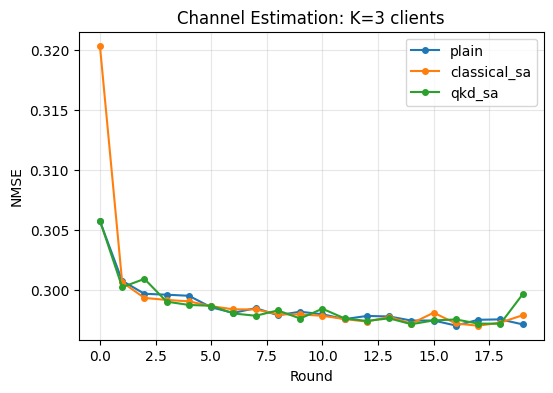

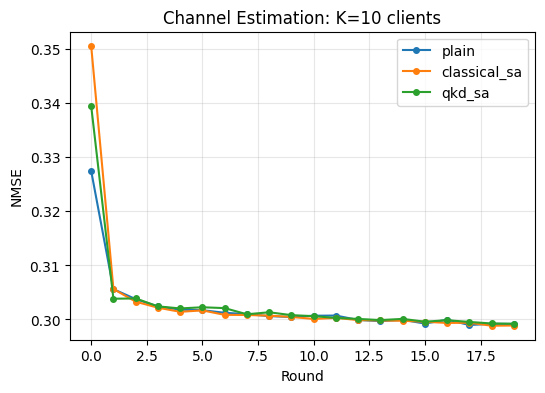

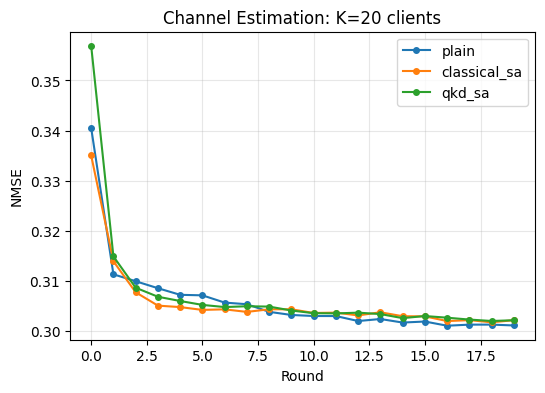

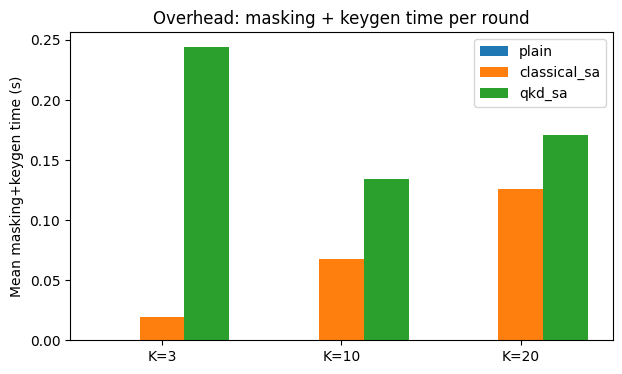

Results saved to outputs/channel_estimation/


In [11]:
# Save results and plots to outputs/channel_estimation/

base = ensure_output_dirs(TASK)
df_summary.to_csv(os.path.join(base, "results_summary.csv"), index=False)
df_rounds.to_csv(os.path.join(base, "results_rounds.csv"), index=False)
with open(os.path.join(base, "results_summary.json"), "w") as f:
    f.write(df_summary.to_json(orient="records", indent=2))

# Plot 1: NMSE vs round for each K (3 lines: plain, classical_sa, qkd_sa)
for K in K_VALS:
    fig, ax = plt.subplots(figsize=(6, 4))
    for mode in MODES:
        key = (K, mode)
        if key not in full_results:
            continue
        nmse = full_results[key]["round_nmse"]
        ax.plot(range(len(nmse)), nmse, label=mode, marker="o", markersize=4)
    ax.set_xlabel("Round")
    ax.set_ylabel("NMSE")
    ax.set_title(f"Channel Estimation: K={K} clients")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show(fig)
    save_figure(fig, f"nmse_vs_round_K{K}.png", TASK)

# Plot 2: Overhead (masking + keygen time) per round, by K and mode
fig2, ax2 = plt.subplots(figsize=(7, 4))
x = np.arange(len(K_VALS))
width = 0.25
for i, mode in enumerate(MODES):
    means = []
    for K in K_VALS:
        sub = df_rounds[(df_rounds["K"] == K) & (df_rounds["mode"] == mode)]
        means.append((sub["masking_time"] + sub["keygen_time"]).mean() if len(sub) > 0 else 0)
    ax2.bar(x + i * width, means, width, label=mode)
ax2.set_xticks(x + width)
ax2.set_xticklabels([f"K={k}" for k in K_VALS])
ax2.set_ylabel("Mean masking+keygen time (s)")
ax2.set_title("Overhead: masking + keygen time per round")
ax2.legend()
plt.show(fig2)
save_figure(fig2, "overhead_mask_keygen.png", TASK)

print(f"Results saved to {base}/")

In [12]:
# SECTION 6 — Experiments A/B/C

"""Experiment A: Baseline FL vs Secure FL (pairwise masked).
Experiment B: Secure FL with Eve present every round.
Experiment C: Noise sweep for QBER sensitivity.
"""

# Package client_data for convenience (list of DataLoaders)
client_data = client_loaders

EXP_C_ROUNDS = 5

exp_a_baseline = None
exp_a_secure   = None
exp_b          = None
exp_c_results  = None

if FORCE_RECOMPUTE or not os.path.exists(os.path.join(RESULTS_DIR, "exp_a_baseline.npy")):
    print("Running Experiment A: baseline (no QKD / masking)...")
    exp_a_baseline = run_experiment(n_rounds=NUM_ROUNDS,
                                    n_clients=NUM_CLIENTS,
                                    use_qkd=False,
                                    client_data=client_data,
                                    val_loader=val_loader)

    print("Running Experiment A: secure (QKD + pairwise masked)...")
    exp_a_secure = run_experiment(n_rounds=NUM_ROUNDS,
                                  n_clients=NUM_CLIENTS,
                                  use_qkd=True,
                                  eve_every_round=False,
                                  client_data=client_data,
                                  val_loader=val_loader)

    print("Running Experiment B: secure with Eve every round...")
    exp_b = run_experiment(n_rounds=NUM_ROUNDS,
                            n_clients=NUM_CLIENTS,
                            use_qkd=True,
                            eve_every_round=True,
                            client_data=client_data,
                            val_loader=val_loader)

    np.save(os.path.join(RESULTS_DIR, "exp_a_baseline.npy"), exp_a_baseline, allow_pickle=True)
    np.save(os.path.join(RESULTS_DIR, "exp_a_secure.npy"),   exp_a_secure,   allow_pickle=True)
    np.save(os.path.join(RESULTS_DIR, "exp_b.npy"),          exp_b,          allow_pickle=True)
else:
    exp_a_baseline = np.load(os.path.join(RESULTS_DIR, "exp_a_baseline.npy"), allow_pickle=True).item()
    exp_a_secure   = np.load(os.path.join(RESULTS_DIR, "exp_a_secure.npy"),   allow_pickle=True).item()
    exp_b          = np.load(os.path.join(RESULTS_DIR, "exp_b.npy"),          allow_pickle=True).item()

# Experiment C: channel noise sweep
noise_levels = np.linspace(0.0, 0.20, 9)
exp_c_results = []
for eta in tqdm(noise_levels, desc="Experiment C"):
    res = run_experiment(n_rounds=EXP_C_ROUNDS,
                         n_clients=NUM_CLIENTS,
                         use_qkd=True,
                         eve_every_round=False,
                         channel_noise=eta,
                         client_data=client_data,
                         val_loader=val_loader)
    mean_qber = float(np.mean(res["qber_history"]))
    abort_count = int(res["round_status"].count("ABORTED"))
    exp_c_results.append({"noise": float(eta), "mean_qber": mean_qber, "abort_count": abort_count})

exp_c_results = pd.DataFrame(exp_c_results)
print("Experiments A, B, C complete.")

Running Experiment A: baseline (no QKD / masking)...


Round:   0%|          | 0/20 [00:00<?, ?it/s]

Clients:   0%|          | 0/3 [00:00<?, ?it/s]

Round 00: SECURE | NMSE=3.0233e-01 | QBER=0.0000


Clients:   0%|          | 0/3 [00:00<?, ?it/s]

...

Round 03: RECOVERED | NMSE=3.0035e-01 | QBER=0.0723


Round:   0%|          | 0/5 [00:00<?, ?it/s]

Round:   0%|          | 0/5 [00:00<?, ?it/s]

Round:   0%|          | 0/5 [00:00<?, ?it/s]

Experiments A, B, C complete.


In [13]:
# ------------------------------------------------------------------
# Table 7: Channel Estimation — Experiment B: Threat Model
# ------------------------------------------------------------------
from pathlib import Path

def count_round_status(exp):
    statuses = exp["round_status"]
    return {
        "Rounds": len(statuses),
        "Secure": statuses.count("SECURE"),
        "Aborted": statuses.count("ABORTED"),
        "Recovered": statuses.count("RECOVERED"),
    }

table7_rows = []

for label, exp in [
    ("Baseline", exp_a_baseline),
    ("Secure", exp_a_secure),
    ("Eve (all rounds)", exp_b),
]:
    counts = count_round_status(exp)
    table7_rows.append({
        "Mode": label,
        "Rounds": counts["Rounds"],
        "Secure": counts["Secure"],
        "Aborted": counts["Aborted"],
        "Recovered": counts["Recovered"],
    })

table7_df = pd.DataFrame(table7_rows)

out_dir = Path("outputs/channel_estimation/pub")
out_dir.mkdir(parents=True, exist_ok=True)

# Save the paper-aligned CSV
table7_csv_path = out_dir / "table7_threat_model.csv"
table7_df.to_csv(table7_csv_path, index=False)

print("Saved:", table7_csv_path)
display(table7_df)

Saved: outputs/channel_estimation/pub/table7_threat_model.csv


,Mode,Rounds,Secure,Aborted,Recovered
0,Baseline,20,20,0,0
1,Secure,20,20,0,0
2,Eve (all rounds),20,0,20,0


In [14]:
# ------------------------------------------------------------------
# Table 10: Channel Estimation — Leakage Proxies (Secure Mode, Sample Rounds)
# ------------------------------------------------------------------

import pandas as pd
from pathlib import Path

# choose the sample rounds used in the paper
sample_rounds = [0, 2, 4]

table10_rows = []
for r in sample_rounds:
    table10_rows.append({
        "Round": r,
        "NMSE": float(exp_a_secure["round_nmse"][r]),
        "QBER": float(exp_a_secure["qber_history"][r]),
        "Cosine r": float(exp_a_secure["leakage_cosine"][r]),
        "Pearson r": float(exp_a_secure["leakage_pearson"][r]),
    })

table10_df = pd.DataFrame(table10_rows)

out_dir = Path("outputs/channel_estimation/pub")
out_dir.mkdir(parents=True, exist_ok=True)

table10_csv_path = out_dir / "table10_leakage_proxies.csv"
table10_df.to_csv(table10_csv_path, index=False)

print("Saved:", table10_csv_path)
display(table10_df)

Saved: outputs/channel_estimation/pub/table10_leakage_proxies.csv


,Round,NMSE,QBER,Cosine r,Pearson r
0,0,0.303142,0.0,0.986607,0.986556
1,2,0.299682,0.0,0.983730,0.983656
2,4,0.299252,0.0,0.977654,0.977647


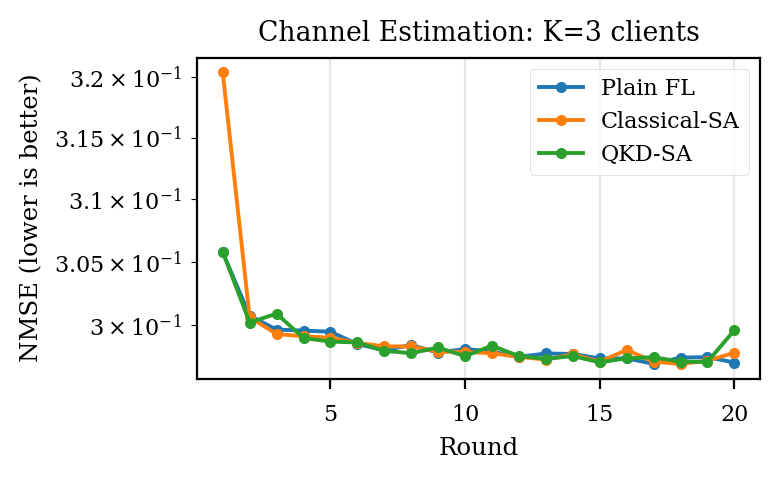

Saved: outputs/channel_estimation/pub/ce_learning_curve_K3.pdf


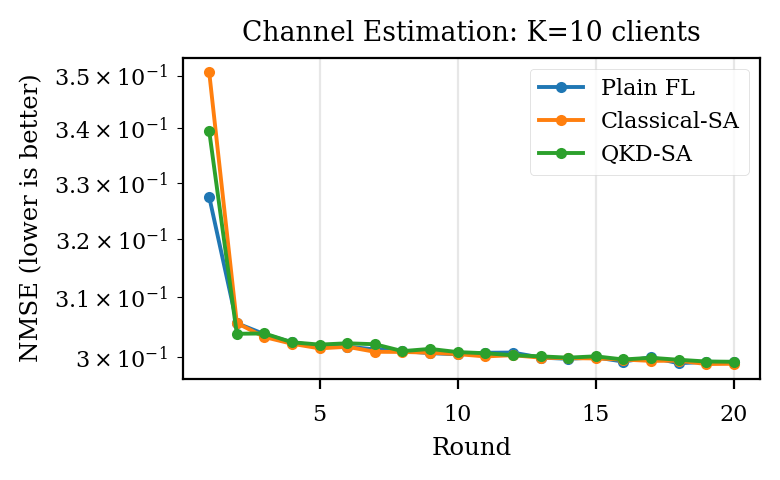

Saved: outputs/channel_estimation/pub/ce_learning_curve_K10.pdf


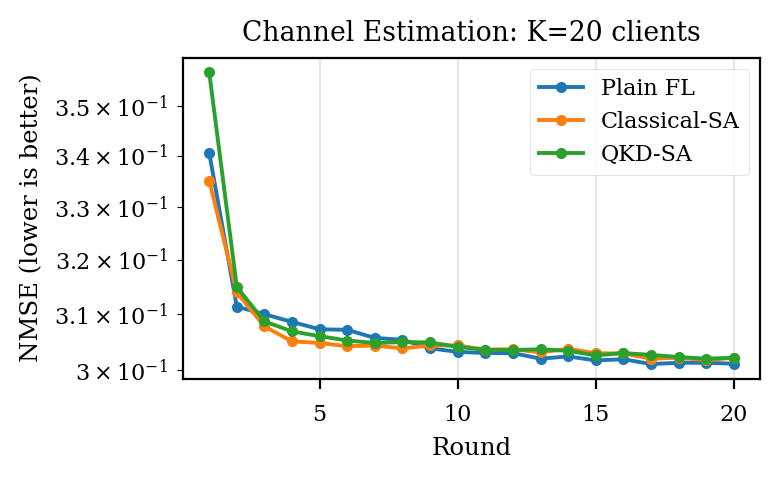

Saved: outputs/channel_estimation/pub/ce_learning_curve_K20.pdf


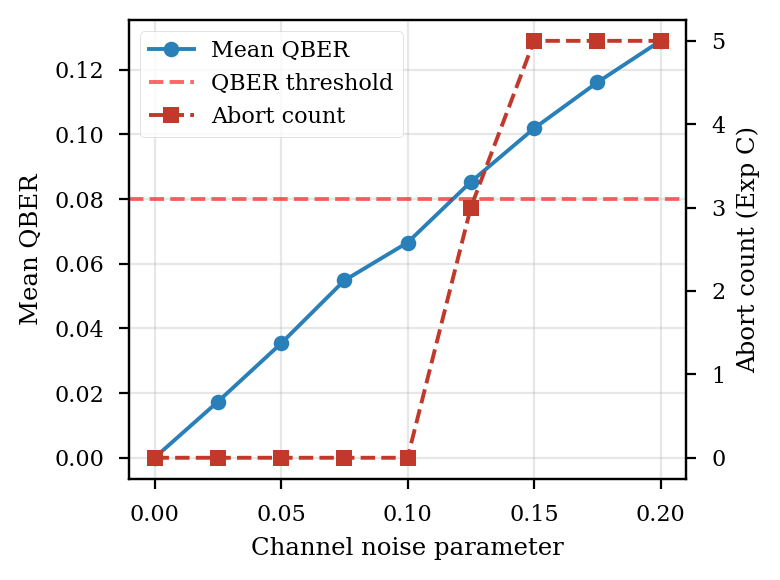

Saved: outputs/channel_estimation/pub/ce_qber_sensitivity.pdf


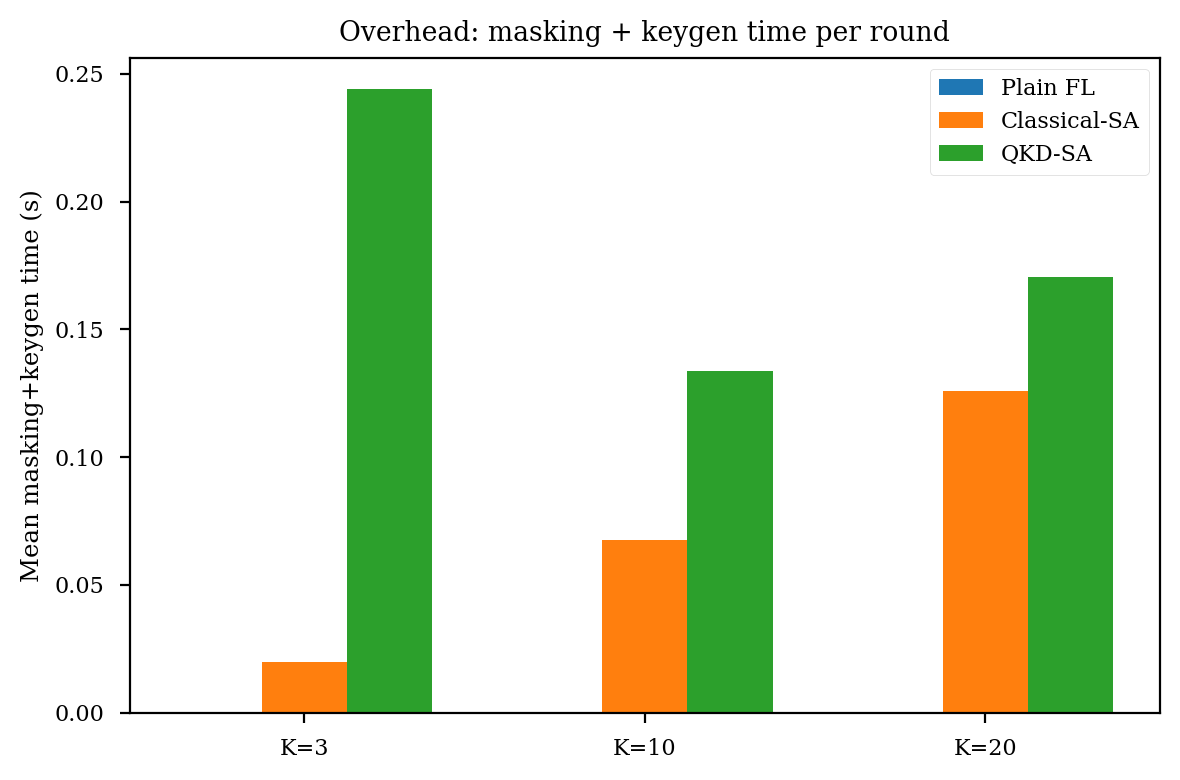

Saved: outputs/channel_estimation/pub/ce_overhead_mask_keygen.pdf
Saved: outputs/channel_estimation/pub/round_metrics_tvt.csv
Saved: outputs/channel_estimation/pub/table_utility_security_cost.csv
Saved: outputs/channel_estimation/pub/table_threat_model_outcomes.csv


In [15]:
# SECTION 7 — Publication-Ready Outputs (Plots + Tables)
# Supports K ∈ {3, 10, 20} from TVT experiments. Falls back to Experiments A/B/C when TVT data unavailable.

try:
    plt.style.use('seaborn-v0_8-paper')
except OSError:
    try:
        plt.style.use('seaborn-paper')
    except OSError:
        pass

plt.rc('text', usetex=False)
plt.rc('font', family='serif')

# Use TVT outputs when available (full_results, df_summary, df_rounds from Section 6)
use_tvt = 'full_results' in dir() and full_results and 'df_summary' in dir() and df_summary is not None
if use_tvt:
    K_VALS_PUB = list(df_summary["K"].unique())
    MODES_PUB = ["plain", "classical_sa", "qkd_sa"]
    mode_labels = {"plain": "Plain FL", "classical_sa": "Classical-SA", "qkd_sa": "QKD-SA"}
else:
    K_VALS_PUB = [3]
    MODES_PUB = []

# Use TVT output dir when using TVT data; else RESULTS_DIR
pub_dir = os.path.join(ensure_output_dirs("channel_estimation"), "pub") if use_tvt else os.path.join(RESULTS_DIR, "pub")
os.makedirs(pub_dir, exist_ok=True)

# --- Learning curve: NMSE vs round (per K: plain, classical_sa, qkd_sa) ---
if use_tvt:
    for K in K_VALS_PUB:
        fig, ax = plt.subplots(figsize=(4, 2.5), dpi=200)
        for mode in MODES_PUB:
            key = (K, mode)
            if key not in full_results:
                continue
            nmse = full_results[key]["round_nmse"]
            lbl = mode_labels.get(mode, mode)
            ax.plot(range(1, len(nmse) + 1), nmse, 'o-', label=lbl, markersize=4)
        ax.set_xlabel('Round')
        ax.set_ylabel('NMSE (lower is better)')
        ax.set_title(f'Channel Estimation: K={K} clients')
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
        ax.legend()
        fig.tight_layout()
        fig.savefig(os.path.join(pub_dir, f'ce_learning_curve_K{K}.pdf'), bbox_inches='tight', dpi=300)
        plt.show()
        print(f"Saved: {os.path.join(pub_dir, f'ce_learning_curve_K{K}.pdf')}")
else:
    # Fallback: Experiments A/B/C (K=3 only)
    if 'exp_a_baseline' in dir() and exp_a_baseline is not None:
        fig, ax = plt.subplots(figsize=(4, 2), dpi=200)
        rnds = np.arange(1, NUM_ROUNDS + 1)
        ax.plot(rnds, exp_a_baseline["round_nmse"], 'o-', label='Baseline FL', color='#3498db')
        ax.plot(rnds, exp_a_secure["round_nmse"],   's-', label='Secure FL (masked)', color='#27ae60')
        ax.plot(rnds, exp_b["round_nmse"],          '^--', label='Exp B (Eve every round)', color='#e74c3c')
        aborted_rounds = [i+1 for i, s in enumerate(exp_b["round_status"]) if s == "ABORTED"]
        if aborted_rounds:
            ax.axvline(x=aborted_rounds[0], color='gray', linestyle=':', alpha=0.7)
        ax.set_xlabel('Round')
        ax.set_ylabel('NMSE (lower is better)')
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
        ax.legend()
        fig.tight_layout()
        fig.savefig(os.path.join(pub_dir, 'ce_learning_curve_K3.pdf'), bbox_inches='tight', dpi=300)
        plt.show()
        print(f"Saved: {os.path.join(pub_dir, 'ce_learning_curve_K3.pdf')}")

# --- Reconstruction error (exp_a only; TVT does not compute this) ---
if not use_tvt and 'exp_a_secure' in dir() and exp_a_secure is not None:
    if any("recon_err" in rm and not np.isnan(rm.get("recon_err", np.nan)) for rm in exp_a_secure["round_metrics"]):
        fig, ax = plt.subplots(figsize=(4, 3), dpi=200)
        rnds = np.arange(1, NUM_ROUNDS + 1)
        recon_errs = [rm["recon_err"] for rm in exp_a_secure["round_metrics"]]
        ax.plot(rnds, recon_errs, 'o-', color='#8e44ad')
        ax.set_xlabel('Round')
        ax.set_ylabel('Reconstruction error')
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        fig.savefig(os.path.join(pub_dir, 'ce_reconstruction_error.pdf'), bbox_inches='tight', dpi=300)
        plt.show()
        print(f"Saved: {os.path.join(pub_dir, 'ce_reconstruction_error.pdf')}")

# --- Leakage proxies (exp_a only) ---
if not use_tvt and 'exp_a_secure' in dir() and exp_a_secure is not None and "leakage_cosine" in exp_a_secure:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4, 3), dpi=200, sharex=True)
    rnds_leak = np.arange(1, len(exp_a_secure["leakage_cosine"]) + 1)
    ax1.plot(rnds_leak, exp_a_secure["leakage_cosine"], 'o-', color='#3498db', label='Cosine similarity')
    ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax1.set_ylabel('Cosine similarity')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax2.plot(rnds_leak, exp_a_secure["leakage_pearson"], 's-', color='#e74c3c', label='Pearson correlation')
    ax2.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax2.set_xlabel('Round')
    ax2.set_ylabel('Pearson correlation')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(os.path.join(pub_dir, 'ce_leakage_proxies.pdf'), bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Saved: {os.path.join(pub_dir, 'ce_leakage_proxies.pdf')}")

# --- QBER sensitivity (Exp C only) ---
if 'exp_c_results' in dir() and exp_c_results is not None and len(exp_c_results) > 0:
    fig, ax1 = plt.subplots(figsize=(4, 3), dpi=200)
    ax1.plot(exp_c_results["noise"], exp_c_results["mean_qber"], 'o-', color='#2980b9', label='Mean QBER')
    ax1.axhline(y=QBER_THRESHOLD, color='red', linestyle='--', alpha=0.6, label='QBER threshold')
    ax1.set_xlabel('Channel noise parameter')
    ax1.set_ylabel('Mean QBER')
    ax1.grid(True, alpha=0.3)
    ax2 = ax1.twinx()
    ax2.plot(exp_c_results["noise"], exp_c_results["abort_count"], 's--', color='#c0392b', label='Abort count')
    ax2.set_ylabel('Abort count (Exp C)')
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
    fig.tight_layout()
    fig.savefig(os.path.join(pub_dir, 'ce_qber_sensitivity.pdf'), bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Saved: {os.path.join(pub_dir, 'ce_qber_sensitivity.pdf')}")

# --- Overhead: masking + keygen time per K (TVT only) ---
if use_tvt and 'df_rounds' in dir():
    fig, ax = plt.subplots(figsize=(6, 4), dpi=200)
    x = np.arange(len(K_VALS_PUB))
    width = 0.25
    for i, mode in enumerate(MODES_PUB):
        means = []
        for K in K_VALS_PUB:
            sub = df_rounds[(df_rounds["K"] == K) & (df_rounds["mode"] == mode)]
            means.append((sub["masking_time"] + sub["keygen_time"]).mean() if len(sub) > 0 else 0)
        ax.bar(x + i * width, means, width, label=mode_labels.get(mode, mode))
    ax.set_xticks(x + width)
    ax.set_xticklabels([f"K={k}" for k in K_VALS_PUB])
    ax.set_ylabel('Mean masking+keygen time (s)')
    ax.set_title('Overhead: masking + keygen time per round')
    ax.legend()
    fig.tight_layout()
    fig.savefig(os.path.join(pub_dir, 'ce_overhead_mask_keygen.pdf'), bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Saved: {os.path.join(pub_dir, 'ce_overhead_mask_keygen.pdf')}")

# --- CSV tables ---
if use_tvt:
    rm_path = os.path.join(pub_dir, 'round_metrics_tvt.csv')
    df_rounds.to_csv(rm_path, index=False)
    print(f"Saved: {rm_path}")

    util_path = os.path.join(pub_dir, 'table_utility_security_cost.csv')
    df_summary[["K", "mode", "final_nmse", "bytes_downlink", "bytes_uplink_total"]].to_csv(util_path, index=False)
    print(f"Saved: {util_path}")

    threat_rows = []
    for K in K_VALS_PUB:
        for mode in MODES_PUB:
            sub = df_rounds[(df_rounds["K"] == K) & (df_rounds["mode"] == mode)]
            if len(sub) == 0:
                continue
            statuses = sub["status"].tolist()
            threat_rows.append({
                "K": K, "mode": mode,
                "n_rounds": len(statuses),
                "n_secure": statuses.count("SECURE"),
                "n_aborted": statuses.count("ABORTED"),
                "n_recovered": statuses.count("RECOVERED"),
            })
    threat_df = pd.DataFrame(threat_rows)
    threat_path = os.path.join(pub_dir, 'table_threat_model_outcomes.csv')
    threat_df.to_csv(threat_path, index=False)
    print(f"Saved: {threat_path}")
else:
    if 'exp_a_secure' in dir() and exp_a_secure is not None:
        rm_df = pd.DataFrame(exp_a_secure["round_metrics"])
        rm_path = os.path.join(RESULTS_DIR, 'round_metrics.csv')
        rm_df.to_csv(rm_path, index=False)
        print(f"Saved: {rm_path}")
        final_baseline_nmse = exp_a_baseline["round_nmse"][-1]
        final_secure_nmse = exp_a_secure["round_nmse"][-1]
        bytes_baseline = sum(rm["bytes"] for rm in exp_a_baseline["round_metrics"])
        bytes_secure = sum(rm["bytes"] for rm in exp_a_secure["round_metrics"])
        table_utility = pd.DataFrame([
            {"mode": "baseline", "final_nmse": final_baseline_nmse, "total_bytes": bytes_baseline},
            {"mode": "secure", "final_nmse": final_secure_nmse, "total_bytes": bytes_secure},
        ])
        util_path = os.path.join(RESULTS_DIR, 'table_utility_security_cost.csv')
        table_utility.to_csv(util_path, index=False)
        print(f"Saved: {util_path}")
        threat_rows = []
        for name, exp in [("baseline", exp_a_baseline), ("secure", exp_a_secure), ("eve_every_round", exp_b)]:
            statuses = exp["round_status"]
            threat_rows.append({"mode": name, "n_rounds": len(statuses),
                "n_secure": statuses.count("SECURE"), "n_aborted": statuses.count("ABORTED"),
                "n_recovered": statuses.count("RECOVERED")})
        threat_df = pd.DataFrame(threat_rows)
        threat_path = os.path.join(RESULTS_DIR, 'table_threat_model_outcomes.csv')
        threat_df.to_csv(threat_path, index=False)
        print(f"Saved: {threat_path}")

In [16]:
# Run this in your channel estimation notebook after Section experiments run
missing_ce = df_summary[
    (df_summary['mode'] == 'classical_sa') & 
    (df_summary['K'].isin([10, 20]))
][['K', 'mode', 'final_nmse', 'bytes_downlink', 'bytes_uplink_total']]
print(missing_ce.to_string(index=False))

 K         mode  final_nmse  bytes_downlink  bytes_uplink_total
10 classical_sa    0.298878           94212              942120
20 classical_sa    0.302193           94212             1884240


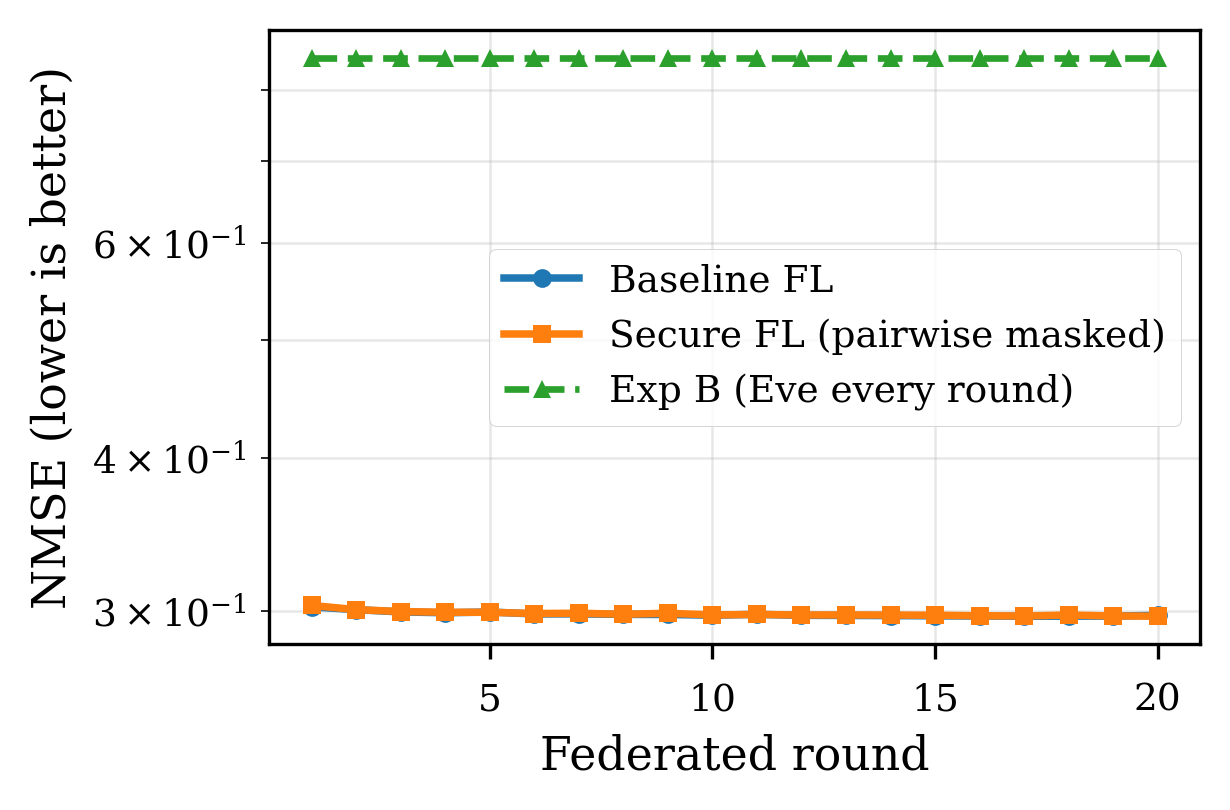

Saved PDF: outputs/channel_estimation/figures/ce_learning_curve_baseline_secure_eve.pdf
Saved PNG: outputs/channel_estimation/figures/ce_learning_curve_baseline_secure_eve.png
Also saved to: ChannelEstimation/20260427_092752/pub


In [18]:
# ============================================================
# Paper Figure: Channel Estimation Learning Curve Only
# Baseline FL vs Secure FL (QKD pairwise masked) vs Eve
# Add this cell at the END of the notebook
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load saved experiment outputs if variables are not in memory
# ------------------------------------------------------------
if "RESULTS_DIR" not in globals():
    raise RuntimeError(
        "RESULTS_DIR is not defined. Please run the notebook first."
    )

if "exp_a_baseline" not in globals() or exp_a_baseline is None:
    exp_a_baseline = np.load(
        os.path.join(RESULTS_DIR, "exp_a_baseline.npy"),
        allow_pickle=True
    ).item()

if "exp_a_secure" not in globals() or exp_a_secure is None:
    exp_a_secure = np.load(
        os.path.join(RESULTS_DIR, "exp_a_secure.npy"),
        allow_pickle=True
    ).item()

if "exp_b" not in globals() or exp_b is None:
    exp_b = np.load(
        os.path.join(RESULTS_DIR, "exp_b.npy"),
        allow_pickle=True
    ).item()

# ------------------------------------------------------------
# Extract curves
# ------------------------------------------------------------
baseline_nmse = np.asarray(exp_a_baseline["round_nmse"], dtype=float)
secure_nmse   = np.asarray(exp_a_secure["round_nmse"], dtype=float)
eve_nmse      = np.asarray(exp_b["round_nmse"], dtype=float)

num_rounds = min(len(baseline_nmse), len(secure_nmse), len(eve_nmse))
rounds = np.arange(1, num_rounds + 1)

baseline_nmse = baseline_nmse[:num_rounds]
secure_nmse   = secure_nmse[:num_rounds]
eve_nmse      = eve_nmse[:num_rounds]

# ------------------------------------------------------------
# Output directory
# ------------------------------------------------------------
fig_dir = os.path.join("outputs", "channel_estimation", "figures")
os.makedirs(fig_dir, exist_ok=True)

pub_dir = os.path.join(RESULTS_DIR, "pub")
os.makedirs(pub_dir, exist_ok=True)

# ------------------------------------------------------------
# Matplotlib style for paper
# ------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(4.2, 2.8), dpi=300)

ax.plot(
    rounds,
    baseline_nmse,
    marker="o",
    linewidth=1.8,
    markersize=4.5,
    label="Baseline FL"
)

ax.plot(
    rounds,
    secure_nmse,
    marker="s",
    linewidth=1.8,
    markersize=4.5,
    label="Secure FL (pairwise masked)"
)

ax.plot(
    rounds,
    eve_nmse,
    marker="^",
    linestyle="--",
    linewidth=1.6,
    markersize=4.5,
    label="Exp B (Eve every round)"
)

ax.set_xlabel("Federated round")
ax.set_ylabel("NMSE (lower is better)")
ax.set_yscale("log")

ax.grid(True, which="both", alpha=0.3, linewidth=0.6)
ax.legend(frameon=True, loc="best")

fig.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
pdf_path = os.path.join(fig_dir, "ce_learning_curve_baseline_secure_eve.pdf")
png_path = os.path.join(fig_dir, "ce_learning_curve_baseline_secure_eve.png")

fig.savefig(pdf_path, bbox_inches="tight", dpi=300)
fig.savefig(png_path, bbox_inches="tight", dpi=300)

fig.savefig(
    os.path.join(pub_dir, "ce_learning_curve_baseline_secure_eve.pdf"),
    bbox_inches="tight",
    dpi=300
)
fig.savefig(
    os.path.join(pub_dir, "ce_learning_curve_baseline_secure_eve.png"),
    bbox_inches="tight",
    dpi=300
)

plt.show()

print(f"Saved PDF: {pdf_path}")
print(f"Saved PNG: {png_path}")
print(f"Also saved to: {pub_dir}")